### This file test the RePercENT model on synthetic data

In [84]:
import sys
import os

sys.path.append(os.getcwd())
# append the root directory to the sys.path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define imports here

In [85]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from src.utils.synthetic_dataset import GenerateData, MultimodalDataset
from src.models.perceiver import Perceiver
from src.models.repercent import DisenEncoder, RePercENT, DisenLoss
import math
from tqdm.notebook import tqdm
from torch.utils.data import random_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [86]:
# device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [87]:
N_data = int(1e5)
latent_dim = {'Zs': 32, 'Z1': 32, 'Z2': 32}
mod_type= "identity"  # "rbf", "random", "identity"
t1, t2 = 5, 10
gamma1, gamma2 = 2.0, 1.0
normalize = False
gen_data = GenerateData(N_data= N_data, mod_type= mod_type, latent_dims= latent_dim)
# gen_data.set_seed(0, device= device)
gen_data.create_dataset(t1= t1, t2= t2, gamma1= gamma1, gamma2= gamma2, normalize= normalize)
gen_data.print_dataset_info()

Modulation matrices not found, creating with default parameters for each modality.
before normalization sample: [[ 0.00481551  0.26925529 -0.23661326  0.12869533 -0.28558588]
 [ 0.00481551  0.26925529 -0.23661326  0.12869533 -0.28558588]
 [ 0.00481551  0.26925529 -0.23661326  0.12869533 -0.28558588]
 [ 0.00481551  0.26925529 -0.23661326  0.12869533 -0.28558588]
 [ 0.00481551  0.26925529 -0.23661326  0.12869533 -0.28558588]]
after normalization sample: [[ 0.00481551  0.26925529 -0.23661326  0.12869533 -0.28558588]
 [ 0.00481551  0.26925529 -0.23661326  0.12869533 -0.28558588]
 [ 0.00481551  0.26925529 -0.23661326  0.12869533 -0.28558588]
 [ 0.00481551  0.26925529 -0.23661326  0.12869533 -0.28558588]
 [ 0.00481551  0.26925529 -0.23661326  0.12869533 -0.28558588]]
X1 shape: (100000, 5, 64), X2 shape: (100000, 10, 64)
Dataset Information:
Number of samples: 100000
Modality 1 data shape: 100000
Labels 1 shape: (100000,), Unique classes: [0 1]
Labels 2 shape: (100000,), Unique classes: [0 1]

In [88]:
dataset = MultimodalDataset(total_data= gen_data.dataset_dict['total_data'], labels_1 = gen_data.dataset_dict['labels_1'], labels_2=gen_data.dataset_dict['labels_2'], labels_s=gen_data.dataset_dict['labels_s'])

### Initialize the encoders for each modality:

$M_1$

In [89]:
# We want be using encoders for the synthetic data experiments, so we define identity encoders
enc_m1 = nn.Identity()

# Initialize the Perceiver module
DEPTH = 2
MAX_FREQ = math.ceil(t1 / 2) # set max freq to Nyquist frequency
NUM_FREQ_BANDS = 3
INPUT_CHANNELS= latent_dim['Z1'] + latent_dim['Zs'] # input channels = dim of unique component 1 + dim of shared component
INPUT_AXIS = 1 
LATENT_HEADS = 1
NUM_LATENTS = 2 # number of latent vectors, i.e. the number of disentangled factors to extract
LATENT_DIM = 32
CROSS_HEADS = 2
POS_ENCODING= True


per_m1 = Perceiver(num_freq_bands= NUM_FREQ_BANDS,
                    latent_dim= LATENT_DIM,
                    num_latents= NUM_LATENTS,
                  depth= DEPTH,
                  max_freq= MAX_FREQ,
                  latent_heads= LATENT_HEADS,
                  cross_heads= CROSS_HEADS,
                  input_channels= INPUT_CHANNELS,
                  input_axis= INPUT_AXIS,
                  fourier_encode_data= POS_ENCODING).to(device)

dissen_m1 = DisenEncoder(encoder_model= enc_m1, perceiver_model= per_m1).to(device)
dissen_m1.__repr__()

DisenEncoder with encoder: Identity() and perceiver: Perceiver(
  (layers): ModuleList(
    (0-1): 2 x ModuleList(
      (0): PreNorm(
        (fn): Attention(
          (to_q): Linear(in_features=32, out_features=128, bias=False)
          (to_kv): Linear(in_features=71, out_features=256, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
          (to_out): Linear(in_features=128, out_features=32, bias=True)
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm_context): LayerNorm((71,), eps=1e-05, elementwise_affine=True)
      )
      (1): PreNorm(
        (fn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=32, out_features=256, bias=True)
            (1): GEGLU()
            (2): Linear(in_features=128, out_features=32, bias=True)
            (3): Dropout(p=0.0, inplace=False)
          )
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
      (2): ModuleList(
  

$M_2$

In [90]:
# We want be using encoders for the synthetic data experiments, so we define identity encoders
enc_m2 = nn.Identity()

# Initialize the Perceiver module
DEPTH = 2
MAX_FREQ = math.ceil(t2 / 2) # set max freq to Nyquist frequency
NUM_FREQ_BANDS = math.floor(math.log2(MAX_FREQ)) + 1
INPUT_CHANNELS= latent_dim['Z2'] + latent_dim['Zs'] # input channels = dim of unique component 2 + dim of shared component
INPUT_AXIS = 1 # input axis = time points of modality 2
LATENT_HEADS = 1
NUM_LATENTS = 2 # number of latent vectors, i.e. the number of disentangled factors to extract
LATENT_DIM = 32
CROSS_HEADS = 2
POS_ENCODING= True


per_m2 = Perceiver(num_freq_bands= NUM_FREQ_BANDS,
                  latent_dim= LATENT_DIM,
                  num_latents= NUM_LATENTS,
                  depth= DEPTH,
                  max_freq= MAX_FREQ,
                  latent_heads= LATENT_HEADS,
                  cross_heads= CROSS_HEADS,
                  input_channels= INPUT_CHANNELS,
                  input_axis= INPUT_AXIS,
                  fourier_encode_data= POS_ENCODING).to(device)

dissen_m2 = DisenEncoder(encoder_model= enc_m2, perceiver_model= per_m2).to(device)
dissen_m2.__repr__()


DisenEncoder with encoder: Identity() and perceiver: Perceiver(
  (layers): ModuleList(
    (0-1): 2 x ModuleList(
      (0): PreNorm(
        (fn): Attention(
          (to_q): Linear(in_features=32, out_features=128, bias=False)
          (to_kv): Linear(in_features=71, out_features=256, bias=False)
          (dropout): Dropout(p=0.0, inplace=False)
          (to_out): Linear(in_features=128, out_features=32, bias=True)
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm_context): LayerNorm((71,), eps=1e-05, elementwise_affine=True)
      )
      (1): PreNorm(
        (fn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=32, out_features=256, bias=True)
            (1): GEGLU()
            (2): Linear(in_features=128, out_features=32, bias=True)
            (3): Dropout(p=0.0, inplace=False)
          )
        )
        (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      )
      (2): ModuleList(
  

### Define the complete module

In [91]:
model = RePercENT(M= 2, disenEncoder= [dissen_m1, dissen_m2]).to(device)

### Tesing fwd pass and Augmentations in data

In [92]:
dataloader = DataLoader(dataset, batch_size= 16, shuffle= True)

for batch_idx, (data_m1, data_m2, labels_1, labels_2, labels_s) in enumerate(dataloader):
    data_m1 = data_m1.to(device)
    data_m2 = data_m2.to(device)
    print("Testing augmentation")

    data_m1_aug = gen_data.augment_data(data_m1, aug_type= "noise", scale= 0.0001)
    data_m1_random_drop = gen_data.augment_data(data_m1, aug_type= "random_drop", drop_scale= 10)
    data_1_swap = gen_data.augment_data(data_m1, aug_type= "swap")
    print("Original Data Modality 1:", data_m1[0, 0, :])
    print("Augmented Data Modality 1 (Noise):", data_m1_aug[0, 0, :])
    print("Augmented Data Modality 1 (Random Drop):", data_m1_random_drop[0, 0, :])
    print("Augmented Data Modality 1 (Swap):", data_1_swap[0, 0, :])
    # outputs = model(data_m1, data_m2)
    # print(f"Batch {batch_idx+1}:")
    # for i, (output, val) in enumerate(outputs.items()):
    #     print(f" Model output {i+1} - {output}: {val}")
    break  # Just process one batch for demonstration

Testing augmentation
Original Data Modality 1: tensor([ 0.0020,  0.5255, -0.1459, -0.0052,  0.3621,  0.4000, -0.3316, -0.3616,
        -1.1254,  0.1260, -0.1020, -0.3721,  0.3415,  0.1261,  0.4288,  0.3950,
         0.0305,  1.0127, -0.0296, -1.0174,  0.3128, -0.0221,  0.2610, -0.2242,
        -0.5086, -0.5517,  0.8244,  0.0658,  0.2545,  0.1434,  0.1921, -0.1790,
         0.1807, -0.0827,  0.3665, -0.0366,  0.0455, -0.3936, -0.2830,  0.0087,
         0.0321, -0.4408,  0.4364, -0.1082,  0.1508, -0.2280, -0.7430,  0.4590,
        -0.1344,  0.1530,  0.1622,  0.2513, -0.2461, -0.2825, -0.6857, -0.3764,
        -0.3357,  0.2054,  0.6056,  0.2024,  0.2622,  0.4591, -0.2716,  0.3356],
       device='cuda:0')
Augmented Data Modality 1 (Noise): tensor([-0.0175,  0.5190, -0.1735, -0.0034,  0.3602,  0.3909, -0.3386, -0.3705,
        -1.1493,  0.1199, -0.1267, -0.3481,  0.3502,  0.1235,  0.4554,  0.4104,
         0.0237,  1.0302, -0.0164, -1.0013,  0.3022, -0.0391,  0.2433, -0.2443,
        -0.50

### Split train test dataset

In [93]:
test_size = 0.2
train_size = int((1 - test_size) * len(dataset))
train_dataset, test_dataset = random_split(dataset, [train_size, len(dataset) - train_size])

### Define helper linear probing function

In [94]:
def linear_probe(train_data, train_labels, test_data, test_labels):
    # Train logistic regression
    clf = LogisticRegression(max_iter= 10000)
    clf.fit(train_data, train_labels)
    
    # Predict and compute accuracy
    labels_pred = clf.predict(test_data)
    acc = accuracy_score(test_labels, labels_pred) * 100  # Convert to percentage
    
    return acc


# extract all the train-data and labels to have them ready for linear probing

def extract_latents_and_labels(model, loader, device):
    model.eval()
    with torch.no_grad():
        for batch_idx, (data_m1, data_m2, labels_1, labels_2, labels_s) in enumerate(loader):
            data_m1 = data_m1.to(device)
            data_m2 = data_m2.to(device)
            labels_1 = labels_1.to(device)
            labels_2 = labels_2.to(device)
            labels_s = labels_s.to(device)
            
            outputs = model(data_m1, data_m2)
            u_12 = outputs['Z1'][0]
            s_21 = outputs['Z2'][1]
            u_21 = outputs['Z2'][0]
            s_12 = outputs['Z1'][1]
            
            if batch_idx == 0:
                all_u12 = u_12
                all_s21 = s_21
                all_u21 = u_21
                all_s12 = s_12
                all_labels_1 = labels_1
                all_labels_2 = labels_2
                all_labels_s = labels_s
            else:
                all_u12 = torch.cat([all_u12, u_12], dim=0)
                all_s21 = torch.cat([all_s21, s_21], dim=0)
                all_u21 = torch.cat([all_u21, u_21], dim=0)
                all_s12 = torch.cat([all_s12, s_12], dim=0)
                all_labels_1 = torch.cat([all_labels_1, labels_1], dim=0)
                all_labels_2 = torch.cat([all_labels_2, labels_2], dim=0)
                all_labels_s = torch.cat([all_labels_s, labels_s], dim=0)
    data_dict = {
        'u_12': all_u12.cpu().numpy(),
        's_21': all_s21.cpu().numpy(),
        'u_21': all_u21.cpu().numpy(),
        's_12': all_s12.cpu().numpy(),
        'labels_1': all_labels_1.cpu().numpy(),
        'labels_2': all_labels_2.cpu().numpy(),
        'labels_s': all_labels_s.cpu().numpy()}
    return data_dict


### Define training loop

In [95]:
# Training loop with logistic regression probing for disentanglement evaluation
# set seed for torch
torch.manual_seed(0)
# clear memory
torch.cuda.empty_cache()
# Training hyperparameters
alpha = 0.5
lmd = 1e-3
EPOCHS = 50
BATCH_SZ = 1024
LR = 1e-3


dissen_loss = DisenLoss(alpha=alpha, lmd=lmd, lmd_end_value= 0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SZ, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SZ, shuffle=False)


# Training logs
train_loss_logs = {
    "loss": [], "loss_ortho": [], "loss_unique": [], "loss_shared": [],
    "acc_u12_l1": [], "acc_s21_ls": [], "acc_u21_l2": [], "acc_s12_ls": []
}

test_loss_logs = {
    "loss": [], "loss_ortho": [], "loss_unique": [], "loss_shared": [],
    "acc_u12_l1": [], "acc_s21_ls": [], "acc_u21_l2": [], "acc_s12_ls": []
}

print(f"Training with device: {device}\n")

# Training loop
for _iter in range(EPOCHS):
    epoch_loss = 0.0
    epoch_ortho_loss = 0.0
    epoch_unique_loss = 0.0
    epoch_shared_loss = 0.0
    
    model.train()
    
    print(f"----- Epoch: {_iter + 1} / {EPOCHS} -----")
    
    # Training phase
    for batch_idx, (data_m1, data_m2, _, _, _) in enumerate(train_dataloader):
        temp_b = data_m1.shape[0]
        data_m1 = data_m1.to(device)
        data_m2 = data_m2.to(device)
        
        # print(f"M1: {data_m1[0, 0, -3:]}, M2: {data_m2[0, 0, -3:]}")
        # Augment data 
        data_m1_aug = gen_data.augment_data(data_m1, aug_type="random")
        data_m2_aug = gen_data.augment_data(data_m2, aug_type="random")
        
        # Forward pass through RePercENT
        outputs = model(data_m1, data_m2)
        outputs_aug = model(data_m1_aug, data_m2_aug)
        
        # Compute disentanglement loss
        loss_train, logs_train = dissen_loss(outputs, outputs_aug)
        
        # Backward pass for RePercENT
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        
        # Track losses
        epoch_loss += loss_train.item()/ temp_b
        epoch_ortho_loss += logs_train["ortho"]/ temp_b
        epoch_unique_loss += logs_train["unique"]/ temp_b
        epoch_shared_loss += logs_train["shared"]/ temp_b
    
    # Epoch statistics
    avg_epoch_loss = epoch_loss / len(train_dataloader)
    avg_ortho_loss = epoch_ortho_loss / len(train_dataloader)
    avg_unique_loss = epoch_unique_loss / len(train_dataloader)
    avg_shared_loss = epoch_shared_loss / len(train_dataloader)
    
    # Log results
    train_loss_logs["loss"].append(avg_epoch_loss)
    train_loss_logs["loss_ortho"].append(avg_ortho_loss)
    train_loss_logs["loss_unique"].append(avg_unique_loss)
    train_loss_logs["loss_shared"].append(avg_shared_loss)


    # Calculate loss on test set
    model.eval()
    with torch.no_grad():
        test_epoch_loss = 0.0
        test_epoch_ortho_loss = 0.0
        test_epoch_unique_loss = 0.0
        test_epoch_shared_loss = 0.0
        
        for batch_idx, (data_m1, data_m2, _, _, _) in enumerate(test_dataloader):
            temp_b = data_m1.shape[0]
            data_m1 = data_m1.to(device)
            data_m2 = data_m2.to(device)
            
            # Augment data 
            data_m1_aug = gen_data.augment_data(data_m1, aug_type="random")
            data_m2_aug = gen_data.augment_data(data_m2, aug_type="random")
            
            # Forward pass through RePercENT
            outputs = model(data_m1, data_m2)
            outputs_aug = model(data_m1_aug, data_m2_aug)
            
            # Compute disentanglement loss
            loss_test, logs_test = dissen_loss(outputs, outputs_aug)
            
            # Track losses
            test_epoch_loss += loss_test.item()/ temp_b
            test_epoch_ortho_loss += logs_test["ortho"]/ temp_b
            test_epoch_unique_loss += logs_test["unique"]/ temp_b
            test_epoch_shared_loss += logs_test["shared"]/ temp_b
        
        # Epoch statistics
        avg_epoch_loss_te = test_epoch_loss / len(test_dataloader)
        avg_ortho_loss_te = test_epoch_ortho_loss / len(test_dataloader)
        avg_unique_loss_te = test_epoch_unique_loss / len(test_dataloader)
        avg_shared_loss_te = test_epoch_shared_loss / len(test_dataloader)
        
        # Log results
        test_loss_logs["loss"].append(avg_epoch_loss_te)
        test_loss_logs["loss_ortho"].append(avg_ortho_loss_te)
        test_loss_logs["loss_unique"].append(avg_unique_loss_te)
        test_loss_logs["loss_shared"].append(avg_shared_loss_te)
    

    print(f"Training  Loss(x 100): {avg_epoch_loss* 100:.5f} | Ortho (x 100): {avg_ortho_loss* 100:.5f} | Unique (x 100): {avg_unique_loss* 100:.5f} | Shared (x 100): {avg_shared_loss* 100:.5f} | Lmd: {dissen_loss.lmd:.6f}, alpha: {dissen_loss.alpha:.6f}")
    print(f"Testing  Loss(x 100): {avg_epoch_loss_te* 100:.5f} | Ortho (x 100): {avg_ortho_loss_te* 100:.5f} | Unique (x 100): {avg_unique_loss_te* 100:.5f} | Shared (x 100): {avg_shared_loss_te* 100:.5f} ")
print("Training complete!")

Training with device: cuda

----- Epoch: 1 / 50 -----
Training  Loss(x 100): 0.79570 | Ortho (x 100): 54.02776 | Unique (x 100): 0.16349 | Shared (x 100): 0.51538 | Lmd: 0.001000, alpha: 0.500000
Testing  Loss(x 100): 0.49753 | Ortho (x 100): 38.45559 | Unique (x 100): 0.04332 | Shared (x 100): 0.33348 
----- Epoch: 2 / 50 -----
Training  Loss(x 100): 0.55788 | Ortho (x 100): 34.68111 | Unique (x 100): 0.05118 | Shared (x 100): 0.37960 | Lmd: 0.001000, alpha: 0.500000
Testing  Loss(x 100): 0.52012 | Ortho (x 100): 31.44044 | Unique (x 100): 0.03023 | Shared (x 100): 0.35896 
----- Epoch: 3 / 50 -----
Training  Loss(x 100): 0.49697 | Ortho (x 100): 29.40995 | Unique (x 100): 0.03133 | Shared (x 100): 0.34284 | Lmd: 0.001000, alpha: 0.500000
Testing  Loss(x 100): 0.56389 | Ortho (x 100): 28.99322 | Unique (x 100): 0.04401 | Shared (x 100): 0.39017 
----- Epoch: 4 / 50 -----
Training  Loss(x 100): 0.40966 | Ortho (x 100): 26.36388 | Unique (x 100): 0.03681 | Shared (x 100): 0.27827 | Lmd:

### Calculate linear probing accuracy

In [96]:
# Linear probing evaluation
print("Extracting latents from train and test datasets...")

# Extract latents and labels from train and test sets
train_data_dict = extract_latents_and_labels(model, train_dataloader, device)
test_data_dict = extract_latents_and_labels(model, test_dataloader, device)

test_loss_logs["linear_probe"] = {"u_12": np.zeros(3), "s_21": np.zeros(3), "u_21": np.zeros(3), "s_12": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating disentanglement for {label}...")
    
    # Unique component of modality 1
    test_loss_logs["linear_probe"]["u_12"][i] = linear_probe(
        train_data_dict['u_12'], train_data_dict[label],
        test_data_dict['u_12'], test_data_dict[label]
    )
    print(f"  Unique component of modality 1 accuracy: {test_loss_logs['linear_probe']['u_12'][i]:.2f}%")
    # Shared component from modality 2
    test_loss_logs["linear_probe"]["s_21"][i] = linear_probe(
        train_data_dict['s_21'], train_data_dict[label],
        test_data_dict['s_21'], test_data_dict[label]
    )
    print(f"  Shared component from modality 2 accuracy: {test_loss_logs['linear_probe']['s_21'][i]:.2f}%")
    # Unique component of modality 2
    test_loss_logs["linear_probe"]["u_21"][i] = linear_probe(
        train_data_dict['u_21'], train_data_dict[label],
        test_data_dict['u_21'], test_data_dict[label]
    )
    print(f"  Unique component of modality 2 accuracy: {test_loss_logs['linear_probe']['u_21'][i]:.2f}%")
    # Shared component from modality 1
    test_loss_logs["linear_probe"]["s_12"][i] = linear_probe(
        train_data_dict['s_12'], train_data_dict[label],
        test_data_dict['s_12'], test_data_dict[label]
    )
    print(f"  Shared component from modality 1 accuracy: {test_loss_logs['linear_probe']['s_12'][i]:.2f}%")

Extracting latents from train and test datasets...

Evaluating disentanglement for labels_1...
  Unique component of modality 1 accuracy: 63.45%
  Shared component from modality 2 accuracy: 54.27%
  Unique component of modality 2 accuracy: 51.12%
  Shared component from modality 1 accuracy: 50.02%

Evaluating disentanglement for labels_2...
  Unique component of modality 1 accuracy: 49.54%
  Shared component from modality 2 accuracy: 50.97%
  Unique component of modality 2 accuracy: 66.33%
  Shared component from modality 1 accuracy: 52.20%

Evaluating disentanglement for labels_s...
  Unique component of modality 1 accuracy: 59.89%
  Shared component from modality 2 accuracy: 77.94%
  Unique component of modality 2 accuracy: 56.07%
  Shared component from modality 1 accuracy: 78.85%


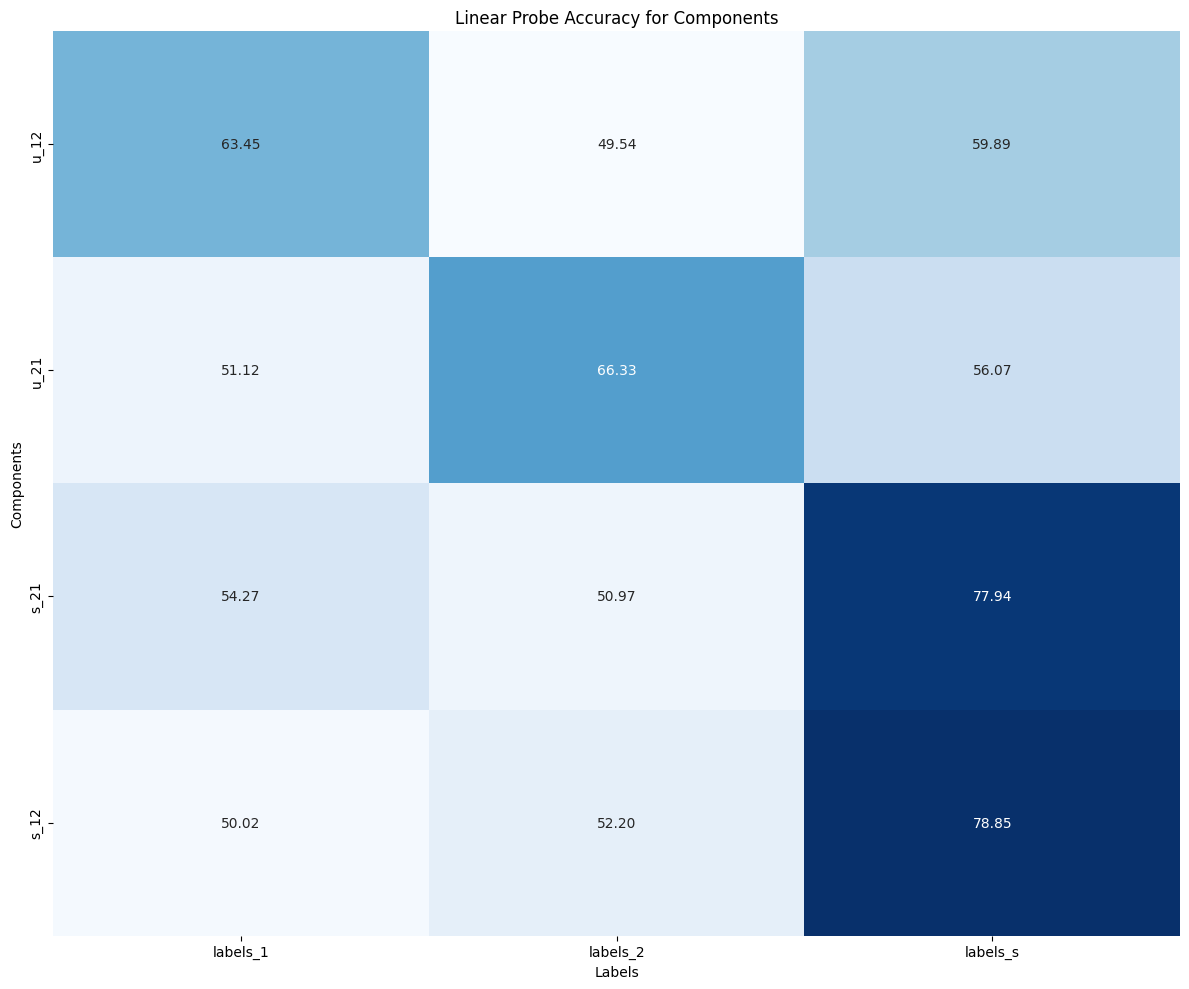

In [97]:
def plot_confusion_matrix(train_loss_logs):
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns

    labels = ['labels_1', 'labels_2', 'labels_s']
    components = ['u_12', 'u_21', 's_21', 's_12']

    fig, axes = plt.subplots(1, 1, figsize=(12, 10))
    

    # Extract the arrays from the dictionary in the specified order
    arrays_to_stack = [train_loss_logs["linear_probe"][key] for key in components]

    # Stack the arrays vertically to create the 4x3 matrix
    result_matrix = np.vstack(arrays_to_stack)
    cm = result_matrix
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=labels, yticklabels=components, ax=axes)
    axes.set_title('Linear Probe Accuracy for Components')
    axes.set_xlabel('Labels')
    axes.set_ylabel('Components')

    plt.tight_layout()
    plt.show()
plot_confusion_matrix(test_loss_logs)

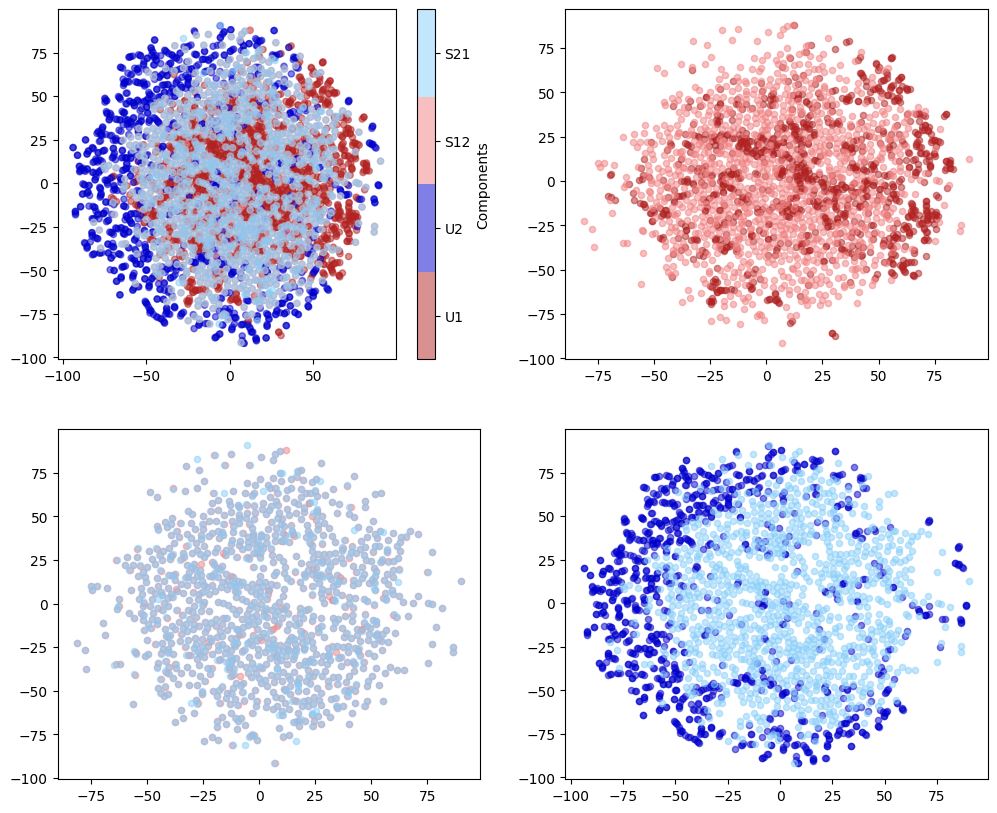

In [98]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
import pickle as pkl

# Extract the disentangled components from the trained model
model.eval()


# Use a batch from the dataset for visualization
dataloader_viz = DataLoader(train_dataset, batch_size=1000, shuffle=False)
data_m1_viz, data_m2_viz, _, _, _ = next(iter(dataloader_viz))

data_m1_viz = data_m1_viz.to(device)
data_m2_viz = data_m2_viz.to(device)

# Forward pass to extract disentangled components
with torch.no_grad():
    outputs_viz = model(data_m1_viz, data_m2_viz)
    
    # Extract components
    z_1 = outputs_viz['Z1'][0].cpu().numpy()  # Unique component from modality 1
    z_2 = outputs_viz['Z2'][0].cpu().numpy()  # Unique component from modality 2
    s_12 = outputs_viz['Z1'][1].cpu().numpy() # shared component from modality 1
    s_21 = outputs_viz['Z2'][1].cpu().numpy() # shared component from modality 2
    
    size = z_1.shape[0]

    labels = [0] * size + [1] * size + size * [2] + size * [3]
    
    # t-SNE 2D visualization
    # Concatenate all components for t-SNE
    concat = np.concatenate([z_1, z_2, s_12, s_21], axis=0)

    # t-SNE 2D visualization
    best_kl = float('inf')
    best_tsne = None
    for i in range(10):
        tsne = TSNE(n_components=2, random_state= i, perplexity=20)
        tsne.fit(concat)
        temp_kl = tsne.kl_divergence_
        if temp_kl < best_kl:
            best_kl = temp_kl
            best_tsne = tsne
    tsne_result = best_tsne.fit_transform(concat)

    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    colors = ['#b22222', '#0000cd', '#f08080', '#87cefa']  # dark red, light red, dark blue, light blue

    # Create colormap
    cmap = ListedColormap(colors)
    scatter3 = ax[0, 0].scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap= cmap, alpha=0.5, s= 20)

    # Discrete colorbar for four labels
    cbar = fig.colorbar(scatter3, ax=ax[0, 0], ticks=[0, 1, 2, 3], boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5])
    cbar.set_label('Components')
    cbar.set_ticklabels(['U1', 'U2', 'S12', 'S21'])

    ax[0, 1].scatter(tsne_result[:size, 0], tsne_result[:size, 1], c= colors[0], label='U1', alpha=0.5, s=20)
    ax[0, 1].scatter(tsne_result[2*size:3*size, 0], tsne_result[2*size:3*size, 1], c=colors[2], label='S12', alpha=0.5, s=20)


    ax[1, 1].scatter(tsne_result[size:2*size, 0], tsne_result[size:2*size, 1], c= colors[1], label='U2', alpha=0.5, s=20)
    ax[1, 1].scatter(tsne_result[3*size:, 0], tsne_result[3*size:, 1], c=colors[3], label='S21', alpha=0.5, s=20)
    
    ax[1, 0].scatter(tsne_result[2*size:3*size, 0], tsne_result[2*size:3*size, 1], c=colors[2], label='S12', alpha=0.5, s=20)
    ax[1, 0].scatter(tsne_result[3*size:, 0], tsne_result[3*size:, 1], c=colors[3], label='S21', alpha=0.5, s=20)
    plt.show()

In [99]:
import pickle

results_dir = '../results/repercent_synthetic/'
os.makedirs(results_dir, exist_ok=True)
# Save the trained model weights as pickle file
model_path = os.path.join(results_dir, 'repercent_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model.state_dict(), f)

# Save training logs as pickle file
logs_path = os.path.join(results_dir, 'training_logs.pkl')
with open(logs_path, 'wb') as f:
    pickle.dump(train_loss_logs, f)

print(f"Model saved to: {model_path}")
print(f"Training logs saved to: {logs_path}")

Model saved to: ../results/repercent_synthetic/repercent_model.pkl
Training logs saved to: ../results/repercent_synthetic/training_logs.pkl


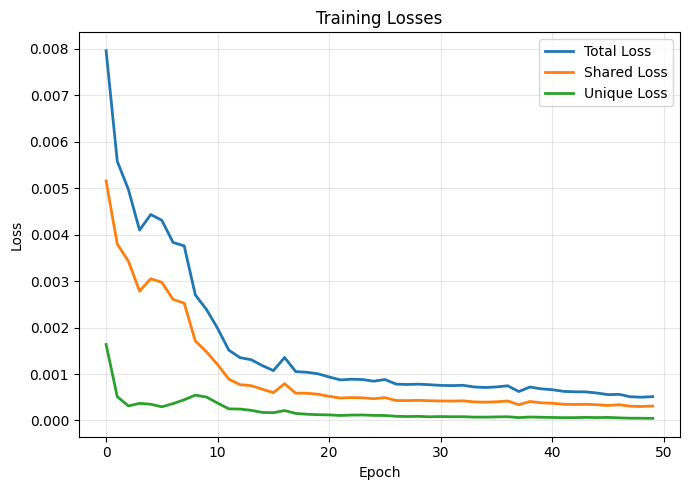

In [100]:
import matplotlib.pyplot as plt

# Plot training losses and accuracies
fig, axes = plt.subplots(1, 1, figsize=(7, 5))

# Loss components
axes.plot(train_loss_logs["loss"], label="Total Loss", linewidth=2)
axes.plot(train_loss_logs["loss_shared"], label="Shared Loss", linewidth=2)
axes.plot(train_loss_logs["loss_unique"], label="Unique Loss", linewidth=2)
# axes.plot(train_loss_logs["loss_ortho"], label="Ortho Loss", linewidth=2)

axes.set_xlabel("Epoch")
axes.set_ylabel("Loss")
axes.set_title("Training Losses")
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
